## 4. Otros Algoritmos de Aprendizaje No Supervisado

### Algoritmo seleccionado: t-SNE (t-Distributed Stochastic Neighbor Embedding)

**¿Por qué t-SNE para este dataset?**

Se eligió t-SNE por tres razones principales:

1. **Validación visual de clusters**: Ya se aplicó K-Means con 4 clusters. t-SNE permite proyectar las 15 dimensiones a 2D y verificar visualmente si los grupos tienen coherencia y separación real.
2. **Estructura no lineal**: Con ~19,000 películas y 15 variables de naturaleza heterogénea (presupuesto, popularidad, votos, géneros), PCA solo captura relaciones lineales. t-SNE detecta agrupaciones no lineales que PCA no revela.
3. **Comunicación de resultados**: Una visualización 2D intuitiva es mucho más útil para CineVision Studios que una tabla de componentes, ya que permite identificar de un vistazo qué películas son similares entre sí.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')

df = pd.read_csv('movies_data_clean.csv', encoding='utf-8', encoding_errors='ignore')
print(f'Dataset: {df.shape[0]:,} películas, {df.shape[1]} variables')
df.head(3)

Dataset: 19,883 películas, 15 variables


,budget,revenue,runtime,video,actorsPopularity_mean,popularity,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
0,12000000.0,38587181.0,95,0,0.372787,0.0357,0.0,0,2,0,0,8,2.0,5.0,2026.0
1,12000000.0,38587181.0,3,0,0.001775,0.0357,0.0,0,1,0,0,4,0.0,0.0,2026.0
2,12000000.0,38587181.0,2,0,0.011200,0.0214,0.0,0,1,0,0,3,0.0,0.0,2026.0


### Preprocesamiento

Se aplica el mismo preprocesamiento usado en Clustering: cap de outliers en el percentil 98 para `castMenAmount`, `castWomenAmount` y `actorsAmount`, imputación de ceros en `budget` y `revenue` con la mediana, y estandarización con StandardScaler.

In [2]:
# Cap de outliers (consistente con sección de Clustering)
for col in ['castMenAmount', 'castWomenAmount', 'actorsAmount']:
    cap = df[col].quantile(0.98)
    df[col] = df[col].clip(upper=cap)

df['budget']  = df['budget'].replace(0, np.nan).fillna(df['budget'].median())
df['revenue'] = df['revenue'].replace(0, np.nan).fillna(df['revenue'].median())

# Estandarización
scaler = StandardScaler()
X = scaler.fit_transform(df)

# Recuperar labels de K-Means (k=4, igual que sección de Clustering)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)
print('Distribución de clusters:')
pd.Series(cluster_labels).value_counts().sort_index()

Distribución de clusters:


0    8789
1     347
2    9963
3     784
Name: count, dtype: int64

### Muestra representativa

t-SNE tiene complejidad O(n²), por lo que se trabaja con una muestra aleatoria del 15% (~3,000 películas) que mantiene la proporción de clusters original y reduce el tiempo de cómputo a un nivel manejable.

In [3]:
np.random.seed(42)
sample_size = 3000
idx = np.random.choice(len(X), sample_size, replace=False)
X_sample = X[idx]
labels_sample = cluster_labels[idx]
df_sample = df.iloc[idx].copy()

print(f'Muestra: {sample_size:,} películas ({sample_size/len(X)*100:.1f}% del total)')
print('Distribución en muestra:')
pd.Series(labels_sample).value_counts().sort_index()

Muestra: 3,000 películas (15.1% del total)
Distribución en muestra:


0    1327
1      53
2    1490
3     130
Name: count, dtype: int64

### Aplicación de t-SNE con diferentes valores de Perplexity

La **perplexity** controla el balance entre estructura local y global. Se prueban dos valores:
- **Perplexity = 30**: Énfasis en vecindades locales, mejor para detectar clusters pequeños y bien definidos.
- **Perplexity = 50**: Captura más contexto global, útil para ver la distribución general del espacio.

In [5]:
print('Ejecutando t-SNE con perplexity=30...')
tsne_30 = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
emb_30 = tsne_30.fit_transform(X_sample)
print('Listo. Ejecutando t-SNE con perplexity=50...')
tsne_50 = TSNE(n_components=2, perplexity=50, random_state=42, max_iter=1000)
emb_50 = tsne_50.fit_transform(X_sample)
print('Ambos completados.')

Ejecutando t-SNE con perplexity=30...
Listo. Ejecutando t-SNE con perplexity=50...
Ambos completados.


### Visualización 1: Comparación de perplexity coloreado por cluster K-Means

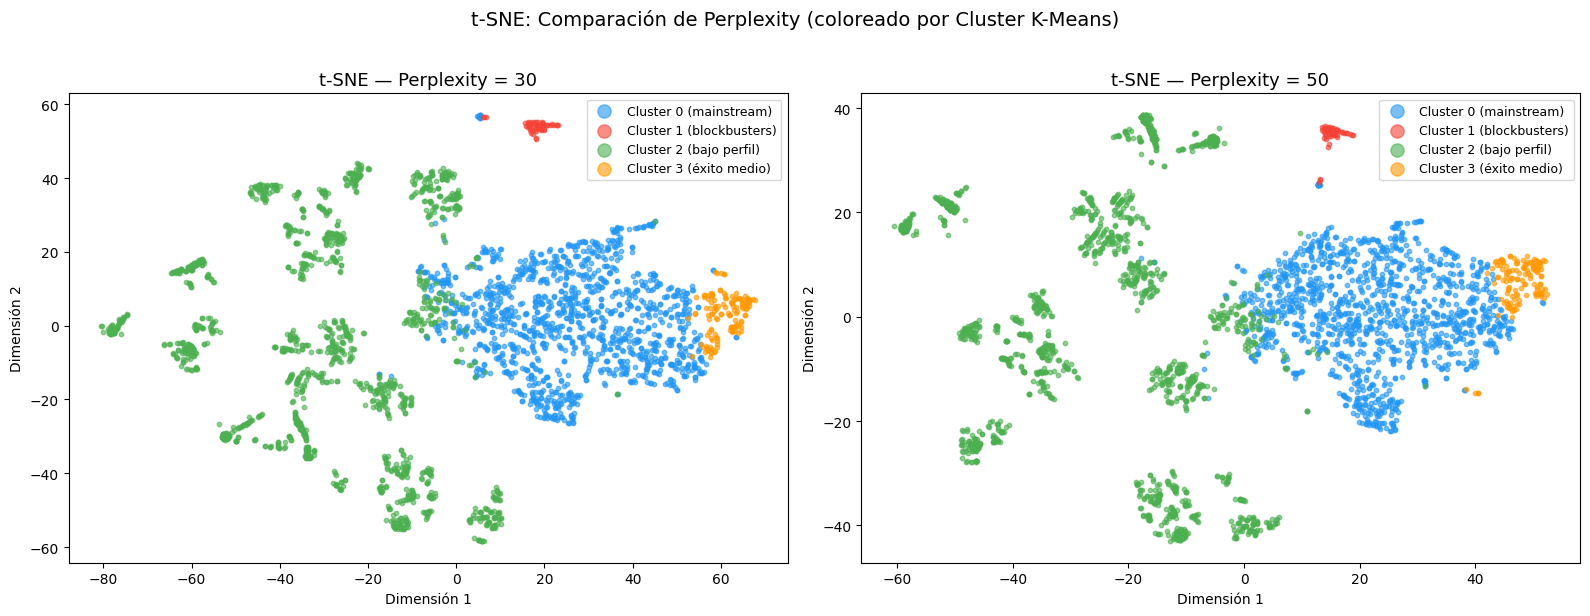

In [6]:
cluster_names = ['Cluster 0 (mainstream)', 'Cluster 1 (blockbusters)',
                 'Cluster 2 (bajo perfil)', 'Cluster 3 (éxito medio)']
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, emb, title in zip(axes, [emb_30, emb_50], ['Perplexity = 30', 'Perplexity = 50']):
    for c in range(4):
        mask = labels_sample == c
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=colors[c], label=cluster_names[c], alpha=0.6, s=10)
    ax.set_title(f't-SNE — {title}', fontsize=13)
    ax.set_xlabel('Dimensión 1')
    ax.set_ylabel('Dimensión 2')
    ax.legend(markerscale=3, fontsize=9)

plt.suptitle('t-SNE: Comparación de Perplexity (coloreado por Cluster K-Means)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Ambas configuraciones de perplexity muestran una estructura similar. Los clusters **1 (blockbusters)** y **3 (éxito medio)** aparecen como grupos compactos y bien separados en el extremo del espacio, confirmando que son grupos con características muy distintas al resto. Los clusters **0** y **2** forman regiones más densas y con cierta superposición, lo que es consistente con sus similitudes encontradas en el análisis de silueta.

### Visualización 2: Coloreado por variables de interés

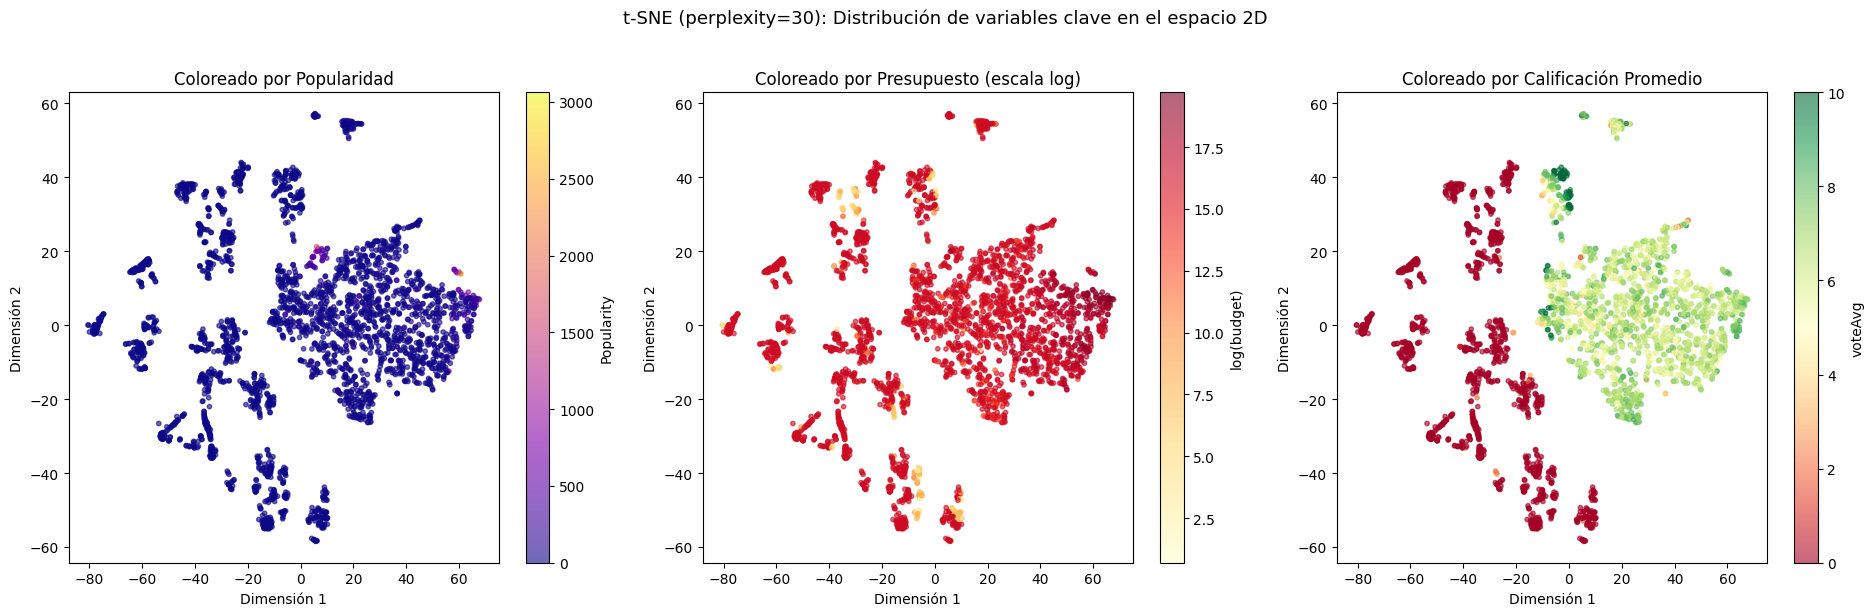

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# Popularidad
sc1 = axes[0].scatter(emb_30[:, 0], emb_30[:, 1],
                      c=df_sample['popularity'].values, cmap='plasma', alpha=0.6, s=10)
plt.colorbar(sc1, ax=axes[0], label='Popularity')
axes[0].set_title('Coloreado por Popularidad', fontsize=12)
axes[0].set_xlabel('Dimensión 1'); axes[0].set_ylabel('Dimensión 2')

# Presupuesto (log)
sc2 = axes[1].scatter(emb_30[:, 0], emb_30[:, 1],
                      c=np.log1p(df_sample['budget'].values), cmap='YlOrRd', alpha=0.6, s=10)
plt.colorbar(sc2, ax=axes[1], label='log(budget)')
axes[1].set_title('Coloreado por Presupuesto (escala log)', fontsize=12)
axes[1].set_xlabel('Dimensión 1'); axes[1].set_ylabel('Dimensión 2')

# Calificación
sc3 = axes[2].scatter(emb_30[:, 0], emb_30[:, 1],
                      c=df_sample['voteAvg'].values, cmap='RdYlGn',
                      alpha=0.6, s=10, vmin=0, vmax=10)
plt.colorbar(sc3, ax=axes[2], label='voteAvg')
axes[2].set_title('Coloreado por Calificación Promedio', fontsize=12)
axes[2].set_xlabel('Dimensión 1'); axes[2].set_ylabel('Dimensión 2')

plt.suptitle('t-SNE (perplexity=30): Distribución de variables clave en el espacio 2D', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Interpretación de resultados

Las visualizaciones de t-SNE revelan información valiosa que complementa el clustering:

**Por popularidad**: Se observa un gradiente claro — las películas más populares se concentran en una región específica del espacio (esquina superior), mientras que la gran mayoría forma una nube densa de baja popularidad. Esto confirma que la popularidad es una dimensión muy discriminante en el dataset.

**Por presupuesto**: Las películas con mayor presupuesto (colores cálidos) se agrupan en zonas distintas y separadas del resto. Esta separación espacial en el embedding de t-SNE valida que el presupuesto es una característica que define grupos coherentes y no está distribuida aleatoriamente.

**Por calificación**: A diferencia del presupuesto y la popularidad, las calificaciones altas (verde) aparecen dispersas en múltiples regiones del mapa, lo que sugiere que la calidad percibida (voteAvg) no está tan fuertemente correlacionada con las demás variables como lo están el presupuesto y la popularidad.

**Validación de clusters**: La separación visual de los 4 clusters en el espacio t-SNE confirma que el agrupamiento K-Means capturó estructuras reales en los datos. En particular, los clusters de blockbusters y éxito medio aparecen como islas bien definidas, mientras que los clusters de películas mainstream y bajo perfil forman regiones más continuas con algo de solapamiento en sus fronteras.

**Relevancia para CineVision Studios**: t-SNE revela que el mercado cinematográfico no es uniforme — existe un espacio de alta popularidad/presupuesto claramente diferenciado del resto, y producir en ese segmento requiere características muy específicas. Las películas de 'zona intermedia' (éxito medio) son las que ofrecen mayor retorno con menor riesgo, como también lo confirmaron las reglas de asociación.